In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### Stage 1.1 — Data Loading & Exploratory Data Analysis (EDA)

In [2]:
#Load the dataset using sklearn.datasets.fetch_california_housing()
from sklearn.datasets import fetch_california_housing


# Load California Housing dataset
data = fetch_california_housing()

In [3]:
X = pd.DataFrame(data.data, columns=data.feature_names)  # input features
y = pd.Series(data.target, name='MedHouseVal')          # target

In [4]:
 X.shape

(20640, 8)

In [5]:
 y.shape

(20640,)

In [6]:
X.head(10)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25


In [7]:
 y.head(10)

0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
5    2.697
6    2.992
7    2.414
8    2.267
9    2.611
Name: MedHouseVal, dtype: float64

In [8]:
### Descriptive Statistics
X.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


In [9]:
y.describe()

count    20640.000000
mean         2.068558
std          1.153956
min          0.149990
25%          1.196000
50%          1.797000
75%          2.647250
max          5.000010
Name: MedHouseVal, dtype: float64

* Some features (like AveRooms, AveBedrms, Population) have outliers; 
 for example, in AveRooms, the maximum value 141.909091 is  higher than the 75% quartile- 6.052381.

* Features show right skewed distribution,
 example: in MedInc the mean value is 3.87067  (slightly higher than) median50% -3.534800.


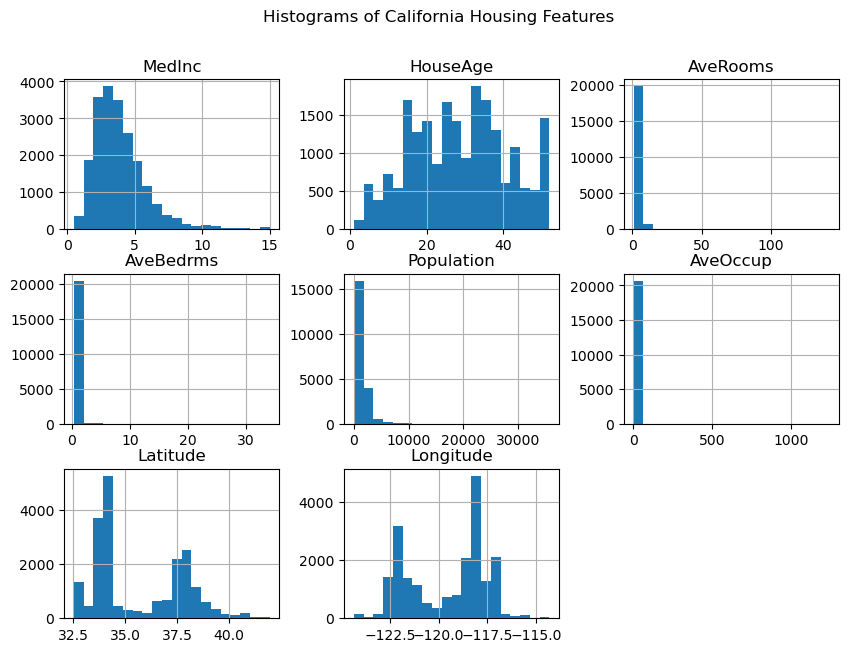

In [10]:
### Visualisations

## Histograms for each features
X.hist(bins=20, figsize=(10,7))
plt.suptitle("Histograms of California Housing Features")


plt.show()


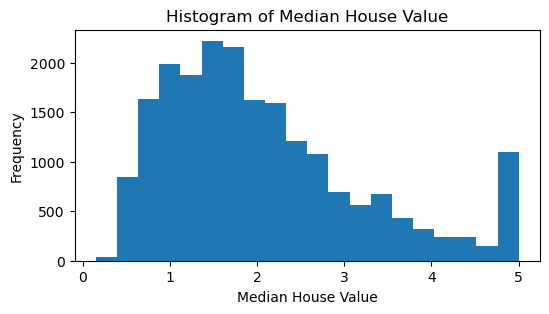

In [11]:
## Histogram for the target variable
plt.figure(figsize=(6,3))
plt.hist(y, bins=20)

plt.title("Histogram of Median House Value")
plt.xlabel("Median House Value")
plt.ylabel("Frequency")

plt.show()


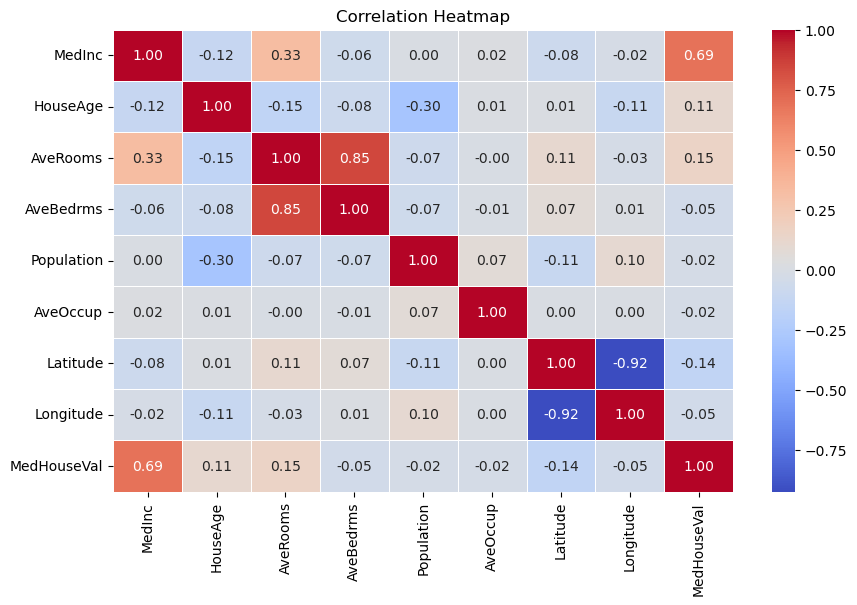

In [12]:

# Combine features and target into one DataFram
df = X.copy()
df["MedHouseVal"] = y

# Calculate correlation matrix
corr_matrix = df.corr()

# Plot heatmap
plt.figure(figsize=(10,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()


* From the heatmap, MedInc shows the strongest positive relationship with MedHouseVal,
* while most other features show weaker relationships.
* also, AveRooms and AveBedrms appear highly related to each other 

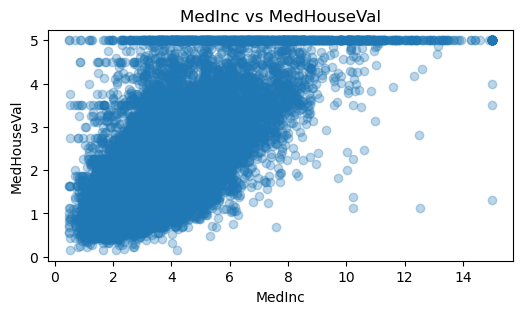

In [13]:
# Plot at least two scatter plots of features vs the target
plt.figure(figsize=(6,3))

plt.scatter(X["MedInc"], y, alpha=0.3)

plt.xlabel("MedInc")
plt.ylabel("MedHouseVal")
plt.title("MedInc vs MedHouseVal")

plt.show()


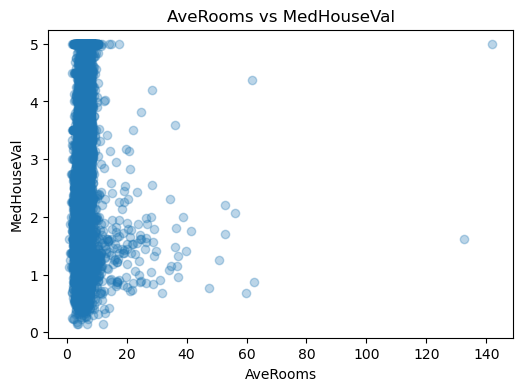

In [14]:
plt.figure(figsize=(6,4))

plt.scatter(X["AveRooms"], y, alpha=0.3)

plt.xlabel("AveRooms")
plt.ylabel("MedHouseVal")
plt.title("AveRooms vs MedHouseVal")

plt.show()


#### Stage 1.2 — Data Preprocessing


In [15]:
### Train/Validation/Test Split

from sklearn.model_selection import train_test_split

In [16]:
#  training (70%) and testing/validation (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42
)

In [17]:
# Split 30% into two equal parts (15% validation, 15% test)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42
)


In [18]:
print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (14448, 8)
Validation shape: (3096, 8)
Test shape: (3096, 8)


The data is split - 70% training, 15% validation, and 15% test sets.
The training set is used to train the model, the validation set is used to
check the model performance during training, and the test set is used for
final evaluation.

In [19]:
### Feature Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()



In [20]:
X_train_scaled = scaler.fit_transform(X_train)

In [21]:
# apply the same scaler to validation and test data
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

* The scaler is fitted only on the training data to avoid data leakage.
* If we use the whole dataset to fit the scaler, the model would indirectly
learn information from the validation and test sets. This cannot give accurate results.
* Therefore, the scaler is fitted on the training data
and then applied to the validation and test sets.


#### Stage 1.3 — Model Architecture Design

In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

In [23]:
# Build model
model = Sequential()

# Input + hidden layer 1
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(BatchNormalization())
model.add(Dropout(0.2))

# hidden layer 2
model.add(Dense(32, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))

# hidden layer 3
model.add(Dense(16, activation='relu'))

# output layer
model.add(Dense(1))

* The hidden layers use 64, 32, and 16 neurons. 
* ReLU activation is used in hidden layers,Helps the model learn complex patterns
* The final layer has one neuron to predict the house value.
* Dropout-> reduce overfitting,Dropout(0.2)->20% neurons are randomly ignored

In [24]:
# model compile
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)


* This is a regression problem  so MSE is used as the loss function. 
* It measures the difference between predicted and actual values and penalises large errors more. 
* MAE is more robust to outliers,  while Huber Loss combines both.


* MAE is used as a performance metric because it measures the average absolute difference 
between predicted and actual values.
* It helps us understand the average prediction error 
in house values.


In [25]:
# model summary
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                576       
                                                                 
 batch_normalization (BatchN  (None, 64)               256       
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 batch_normalization_1 (Batc  (None, 32)               128       
 hNormalization)                                                 
                                                                 
 dropout_1 (Dropout)         (None, 32)                0

#### Stage 1.4 — Model Training

In [26]:
#history = model.fit(
#   X_train_scaled,
#    y_train,
#    epochs=32,
#    validation_data=(X_val_scaled, y_val)
#)


In [27]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


In [31]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_regression_model.keras', monitor='val_loss', save_best_only=True)

In [32]:
# with callbacks
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=32,
    validation_data=(X_val_scaled, y_val),
    callbacks=[early_stop, checkpoint]
)

Epoch 1/32
452/452 [==============================] - 1s 2ms/step - loss: 0.3090 - mae: 0.3896 - val_loss: 0.3303 - val_mae: 0.3957
Epoch 2/32
452/452 [==============================] - 1s 1ms/step - loss: 0.3137 - mae: 0.3921 - val_loss: 0.3225 - val_mae: 0.3932
Epoch 3/32
452/452 [==============================] - 1s 2ms/step - loss: 0.3126 - mae: 0.3933 - val_loss: 0.2980 - val_mae: 0.3719
Epoch 4/32
452/452 [==============================] - 1s 1ms/step - loss: 0.3163 - mae: 0.3933 - val_loss: 0.2944 - val_mae: 0.3756
Epoch 5/32
452/452 [==============================] - 1s 2ms/step - loss: 0.3132 - mae: 0.3918 - val_loss: 0.3087 - val_mae: 0.3892
Epoch 6/32
452/452 [==============================] - 1s 1ms/step - loss: 0.3127 - mae: 0.3912 - val_loss: 0.3019 - val_mae: 0.3769
Epoch 7/32
452/452 [==============================] - 1s 1ms/step - loss: 0.3124 - mae: 0.3913 - val_loss: 0.2942 - val_mae: 0.3732
Epoch 8/32
452/452 [==============================] - 1s 1ms/step - loss: 0.

* Used EarlyStopping to stop training when validation loss stopped improving and
* ModelCheckpoint to save the best model automatically. The training stopped at epoch 17 with the best validation loss.

#### Stage 1.5 — Plotting & Interpreting Training Curves

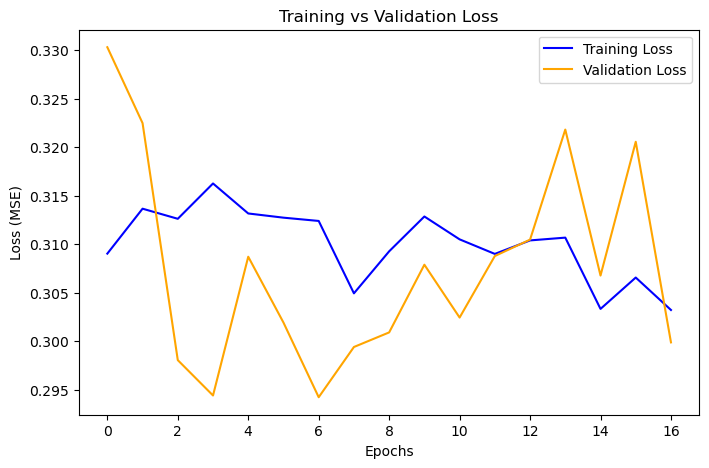

In [33]:
# Plot loss curves
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()


* The model is well-fitted, Training and validation loss are close (0.30 to 0.315) and not very different, so it is not overfitting.
* Validation loss spikes after Epoch 15 → model starts to be unstable.
* Overall, training is steady but validation “bounces” a bit, maybe learning rate is a bit high or batch size is small.


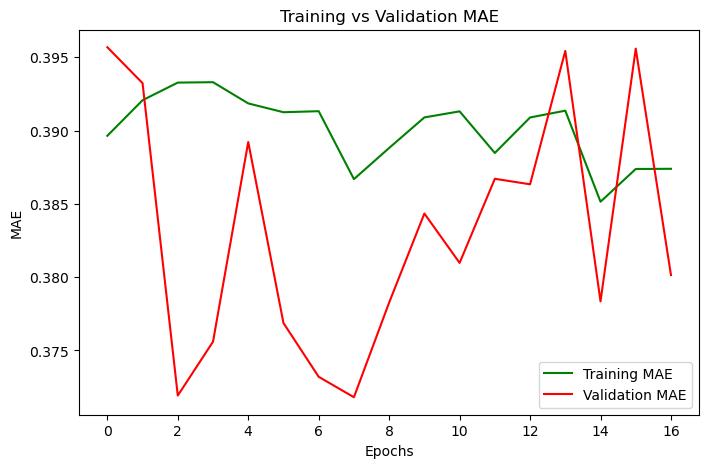

In [34]:
# Plot MAE curves
plt.figure(figsize=(8,5))
plt.plot(history.history['mae'], label='Training MAE', color='green')
plt.plot(history.history['val_mae'], label='Validation MAE', color='red')
plt.title('Training vs Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.show()


* The MAE curve is similar to the loss curve. Validation goes up and down a bit, but the gap with training is small, so the model is learning well

#### Stage 1.6 — Model Evaluation & Analysis

In [35]:
test_loss, test_mae = model.evaluate(X_test_scaled, y_test)
print("Test Loss:", test_loss)
print("Test MAE:", test_mae)


97/97 [==============================] - 0s 1ms/step - loss: 0.2642 - mae: 0.3619
Test Loss: 0.2642320990562439
Test MAE: 0.3619217276573181


In [36]:
# predictions
y_pred = model.predict(X_test_scaled)


97/97 [==============================] - 0s 786us/step


In [37]:
y_pred

array([[0.88327205],
       [1.0892992 ],
       [3.2601104 ],
       ...,
       [1.0051802 ],
       [1.6486648 ],
       [2.827889  ]], dtype=float32)

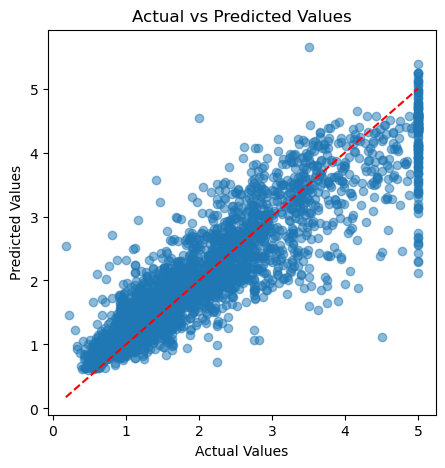

In [38]:
# Plot Actual vs Predicted
plt.figure(figsize=(5,5))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # ideal line y=x
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.show()


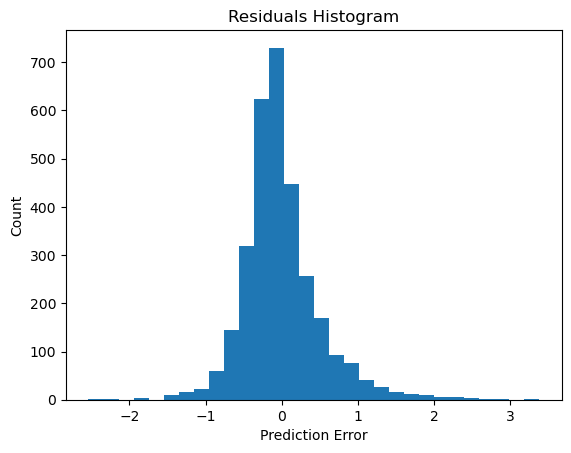

In [39]:
# Plot Residuals (Errors)
errors = y_test - y_pred.flatten()
plt.hist(errors, bins=30)
plt.xlabel("Prediction Error")
plt.ylabel("Count")
plt.title("Residuals Histogram")
plt.show()


The Actual vs Predicted plot shows a strong straight-line trend, so the model is doing well. 
There is a limit at 5.0 because the data doesn’t go higher. 
The residuals are mostly around zero, which shows the model’s errors are small and fair. The largest errors appear at high values, where the model predicts a bit lower than the real value

* The model works well on the test set, similar to validation.

* The biggest mistakes happen with higher-priced houses, where the model sometimes underestimates the value.

* To improve: more data, try different layers, change learning rate or batch size.